In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm #нужна для визуализации прогресса выполнения циклов и длительных операций

In [14]:
df=pd.read_csv('exp_metrics.csv')
df

,user_id,group,sum_time,n_likes
0,176312,A,132.826215,0
1,590324,A,228.852622,1
2,210677,A,43.027297,3
3,962168,B,133.074068,0
4,414385,B,82.268474,0
...,...,...,...,...
58823,643394,B,46.344699,3
58824,587602,A,75.871353,4
58825,837789,B,84.593972,1
58826,358704,A,663.422306,0


**1. Оцените при помощи бутстрепа 95%-ный доверительный интервал для медианы времени (sum_time) в группе В. Каковы получились его границы?**

In [30]:
def get_bootstrap_dist(data, stat, n_iter=10000):
    """
    Делаем выборку с возвратом из наших данных data
    и вычисляем нужную статистику stat.
    Делаем это на протяжении n_iter итераций.
    """
    stats_data = []
    for _ in tqdm(range(n_iter), ncols=80):
        bottstrap_sample = np.random.choice(data, size=len(data), replace=True)
        stats_data.append(stat(bottstrap_sample))
    return stats_data

In [31]:
def plot_dist_with_quantiles(dist, q=0.05):
    ax = sns.histplot(dist, bins=50)
    y_lim = ax.get_ylim()[1]
    median = np.median(dist)
    q1 = np.quantile(dist, q)
    q2 = np.quantile(dist, 1 - q)
    plt.vlines(median, ymin=0, ymax=y_lim, colors='red')
    plt.vlines((q1, q2), ymin=0, ymax=y_lim*0.5, linestyle='--', colors='green')
    plt.title(f"median = {median:,.2f}, q_{q} = {q1:,.2f}, q_{1-q} = {q2:,.2f}")
    plt.show()

100%|████████████████████████████████████| 10000/10000 [00:15<00:00, 634.42it/s]


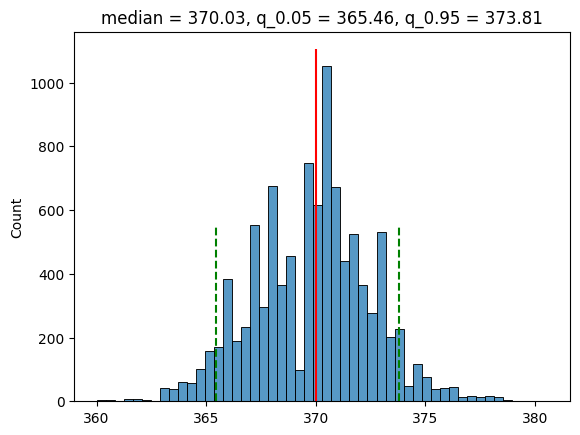

In [32]:
group_B_median_time_dist = get_bootstrap_dist(df[df['group'] == 'B']['sum_time'], stat=lambda x: np.quantile(x, 0.95))
plot_dist_with_quantiles(group_B_median_time_dist)

**Ответ:** границы доверительного интервала для группы В равны 365.47 и 373.81 соответсвенно 

**2. Проверьте, есть ли статистически значимое различие в 90%-ном процентиле (квантиль 0.9) времени (sum_time) между группами А и В на уровне значимости 1% (по 99%-ному доверительному интервалу)**

In [33]:
def get_AB_diff_distribution(data_A, data_B, stat, n_iter=10000):
    diff_data = []
    for _ in tqdm(range(n_iter), ncols=80):
        bottstrap_sample_A = np.random.choice(data_A, size=len(data_A), replace=True)
        bottstrap_sample_B = np.random.choice(data_B, size=len(data_B), replace=True)
        diff = stat(bottstrap_sample_B) - stat(bottstrap_sample_A)
        diff_data.append(diff)
    return diff_data

In [39]:
def plot_dist_with_quantiles(dist, alpha=0.01, q_label=0.9):
    """
    Рисует гистограмму распределения и отмечает 99% ДИ (по уровню значимости alpha).
    """
    ax = sns.histplot(dist, bins=50, kde=False)
    y_lim = ax.get_ylim()[1]

    # Вычисляем границы 99% ДИ (двусторонний)
    lower_ci = np.quantile(dist, alpha / 2)
    upper_ci = np.quantile(dist, 1 - alpha / 2)

    # Медиана и метки
    median = np.median(dist)

    plt.vlines(median, ymin=0, ymax=y_lim, colors='red', label='Медиана')
    plt.vlines([lower_ci, upper_ci], ymin=0, ymax=y_lim * 0.5, 
               linestyle='--', colors='darkorange', label=f'99% ДИ [{lower_ci:.2f}, {upper_ci:.2f}]')

    plt.title(f'Распределение разности 90%-ном процентилей (B − A)\n'
              f'Медиана = {median:.2f}; 99% ДИ = [{lower_ci:.2f}, {upper_ci:.2f}]')
    plt.xlabel('Разность 90%-ных процентилей (B − A)')
    plt.ylabel('Частота')
    plt.legend()
    plt.show()

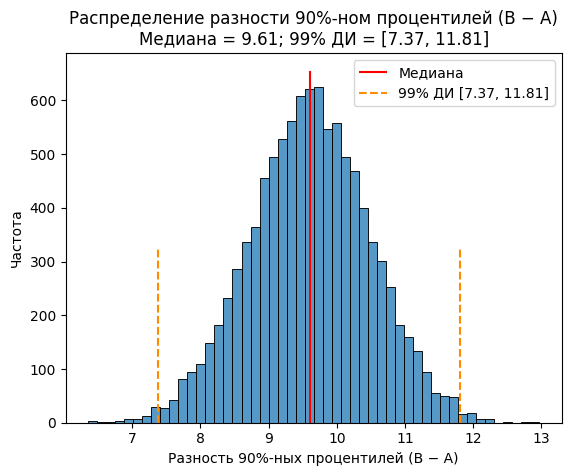

In [40]:
plot_dist_with_quantiles(sum_time_diff, alpha=0.01, q_label=0.9)

**Ответ**: Различие в 90%-ном процентилях времени (sum_time) между группами В и А статистически значимо на уровне 1% (99% ДИ = 7.37, 11.81). Медиана разности составляет 9.61, что указывает на систематическое превышение 90-го процентиля в группе В по сравнению с группой А. Нулевая гипотеза об отсутствии различий отвергается.